#  qPBL

## Loading data

In [3]:
import pennylane as qml
from pennylane import numpy as np
#import numpy as np
from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt
from scipy.linalg import expm

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_ones = x_train[y_train == 2]
x_train_ones_32 = np.pad(x_train_ones, ((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)
Image = x_train_ones_32[0]


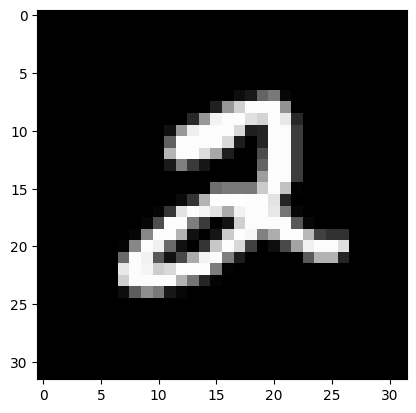

In [5]:
plt.imshow(Image, cmap='gray')
plt.show()

In [6]:
Img = np.cov(Image/255.0)
O = expm(1j * Img)

In [7]:
def int_to_bin(n, num_bits)-> tuple:
        return tuple(int(x) for x in format(n, f'0{num_bits}b'))

## Quantum Circuit

In [24]:
n_qubits = 10
q_qubits = 5
l_qubits = 5
dev = qml.device("default.qubit", wires=n_qubits) #, shots=1000
@qml.qnode(dev)
def ImageEigen(theta, image, control_values=True):
    
    # Definition of the Proyector
    P1 = np.array([[0,0],[0,1]])

    # Optional Hadamards section
    if control_values:
        for i in range(l_qubits,n_qubits):
            qml.Hadamard(wires=i)
    # Mottonen Ansatz
    c = 2**q_qubits -2
    for k,i in enumerate(range(q_qubits-1, -1, -1)):
        for j in range(2**k-1,-1,-1):
            if k>0:
                qml.ctrl(qml.adjoint(qml.RY(theta[c], wires=k+l_qubits)), control=range(l_qubits,k+l_qubits), control_values=int_to_bin(j,k))
            else:
                qml.adjoint(qml.RY(theta[c], wires=k+q_qubits))
            c = c - 1
    
    qml.Barrier()
    
    for i in range(5):
        qml.Hadamard(wires=i)
    qml.ControlledSequence(qml.QubitUnitary(image, wires=range(5,10)),control=range(5))
    qml.adjoint(qml.QFT(wires=range(5)))
    H = np.kron(P1,np.eye(2**(q_qubits -1)))
    return qml.expval(qml.Hermitian(H,wires=range(5)))

(<Figure size 3900x1100 with 1 Axes>, <Axes: >)


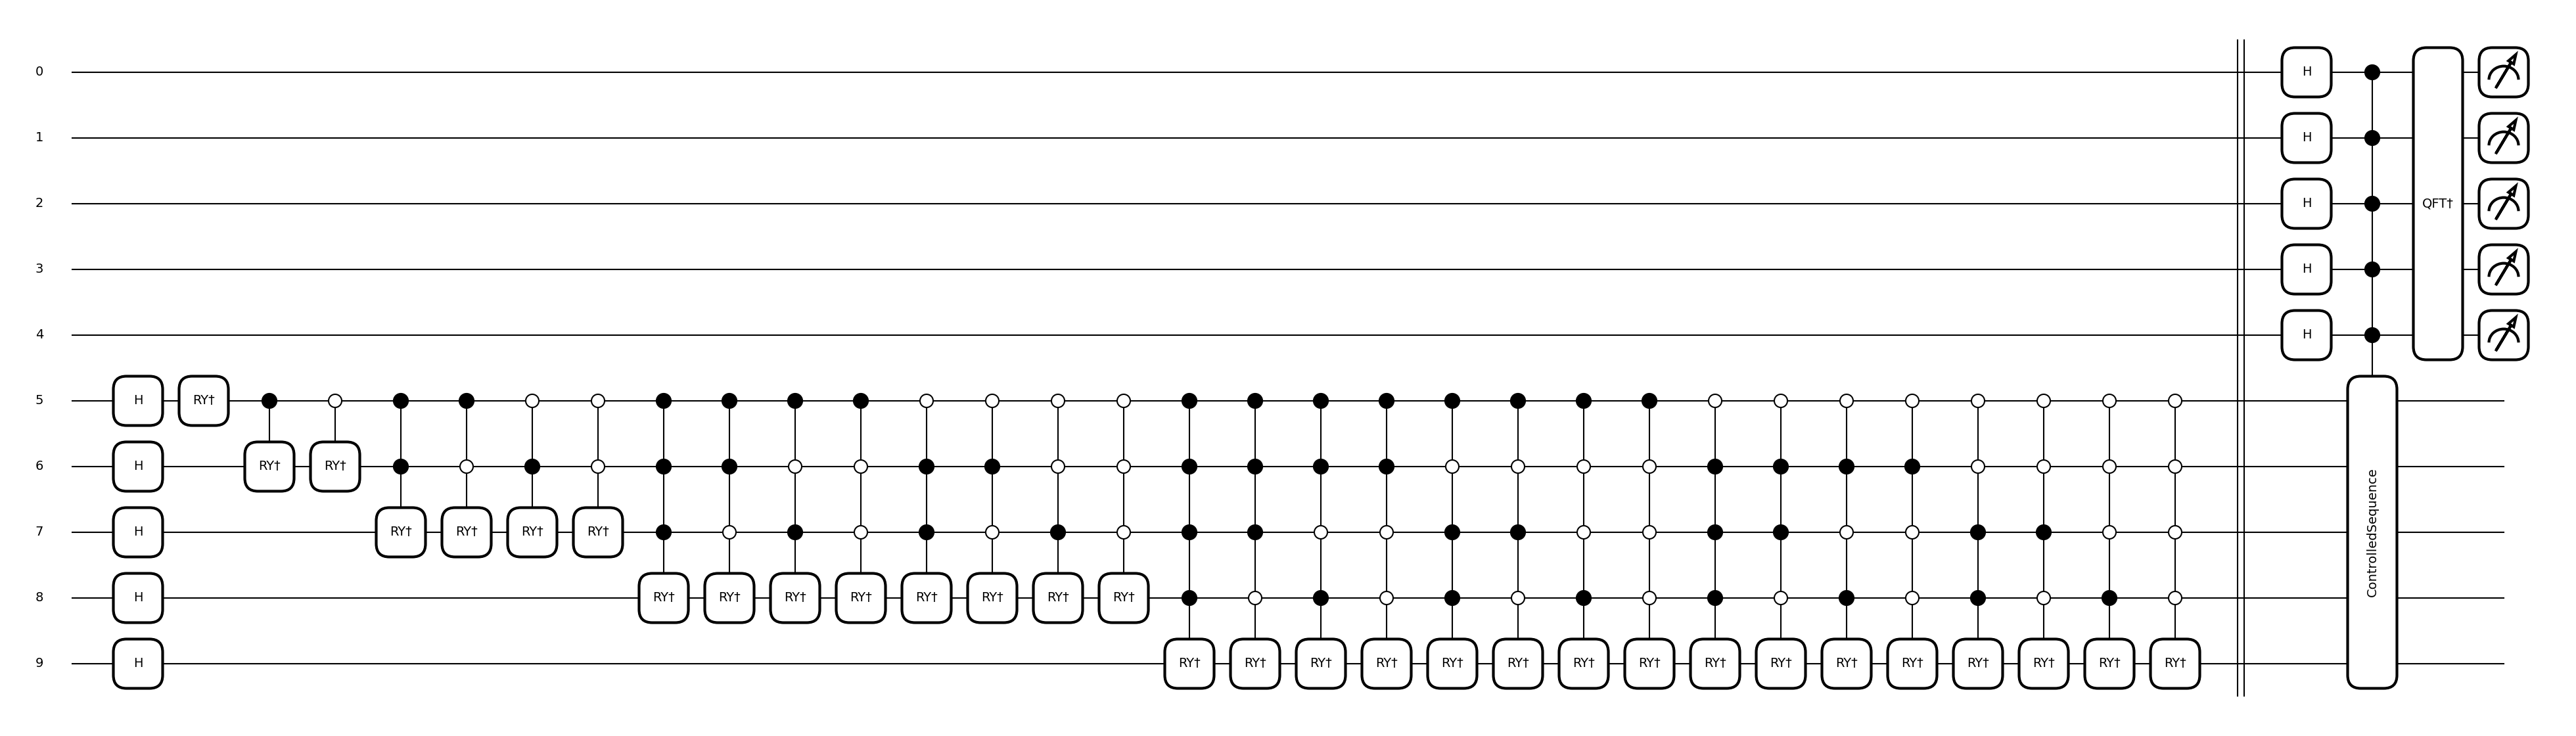

In [25]:
circuit = qml.QNode(ImageEigen,dev)
theta = np.random.uniform(0,2*np.pi,2**q_qubits -1)
print(qml.draw_mpl(circuit)(theta,O))
l = circuit(theta, O)


## Training

In [34]:
def loss_MSE(weights,O):
    """Computes the cost over the provided features and labels"""
    preds = circuit(weights, O, True)
    return np.mean((np.tensor(1.00)-preds) ** 2)

In [35]:
def train(image_data_train, iter=20, lr=0.1):
    weights = np.array(np.random.uniform(0,np.pi,2**q_qubits -1), requires_grad=True) # initialize weights
    opt = qml.GradientDescentOptimizer(stepsize=lr) # gradient optimizer
    for i in range(iter):
        weights, loss = opt.step_and_cost(lambda w: loss_MSE(w, image_data_train), weights)
        if i % 50 == 0:
            print(f"Epoch {i+1}, {loss}:")
    return weights

In [32]:
trained_weights = train(O, iter=100000, lr=0.3)

Epoch 1, 0.9660010451406641:
Epoch 51, 0.9606822456761919:
Epoch 101, 0.9558842259760832:
Epoch 151, 0.9513253841502105:
Epoch 201, 0.946830684349501:
Epoch 251, 0.9424632204627921:
Epoch 301, 0.9384593268818694:
Epoch 351, 0.9350468033104803:
Epoch 401, 0.9323021843777036:
Epoch 451, 0.9301441986837807:
Epoch 501, 0.9284153105430315:
Epoch 551, 0.9269591594562266:
Epoch 601, 0.9256564768652173:
Epoch 651, 0.9244293714758434:
Epoch 701, 0.9232327550980272:
Epoch 751, 0.9220440596572252:
Epoch 801, 0.9208551046398523:
Epoch 851, 0.9196664710241432:
Epoch 901, 0.9184836945569483:
Epoch 951, 0.9173145629405989:
Epoch 1001, 0.9161670505149164:
Epoch 1051, 0.9150476714026877:
Epoch 1101, 0.9139601956234167:
Epoch 1151, 0.9129047419482428:
Epoch 1201, 0.9118772546490648:
Epoch 1251, 0.9108693212716295:
Epoch 1301, 0.9098682305781959:
Epoch 1351, 0.9088571308364496:
Epoch 1401, 0.9078151403999106:
Epoch 1451, 0.9067172831413999:
Epoch 1501, 0.9055341641198624:
Epoch 1551, 0.9042313663185804:


In [159]:
l = circuit(trained_weights, O)
print(l)

[tensor(0.0177402, requires_grad=True)]


In [38]:
l = circuit(trained_weights, O)
print(l)

0.007613268931601875


In [36]:
trained_weights1 = train(O, iter=5000, lr=0.3)

Epoch 1, 0.9768011817830188:
Epoch 51, 0.9668643464683705:
Epoch 101, 0.9546539192377833:
Epoch 151, 0.9414171467045728:
Epoch 201, 0.929064617046009:
Epoch 251, 0.9191760543445096:
Epoch 301, 0.9121465855465061:
Epoch 351, 0.9074347115065368:
Epoch 401, 0.9042756758221014:
Epoch 451, 0.9020529032293718:
Epoch 501, 0.9003478901381041:
Epoch 551, 0.8988873767529312:
Epoch 601, 0.8974858001798494:
Epoch 651, 0.896002655907367:
Epoch 701, 0.8943124908794308:
Epoch 751, 0.8922833433415133:
Epoch 801, 0.889763306822983:
Epoch 851, 0.8865832902728922:
Epoch 901, 0.882598359222562:
Epoch 951, 0.8777987885950063:
Epoch 1001, 0.8724730840141257:
Epoch 1051, 0.8672529862779453:
Epoch 1101, 0.8628311258280553:
Epoch 1151, 0.8595432192231693:
Epoch 1201, 0.8572814824951991:
Epoch 1251, 0.8557377948584507:
Epoch 1301, 0.8546282708116392:
Epoch 1351, 0.853764421445078:
Epoch 1401, 0.853038362539153:
Epoch 1451, 0.8523920181608531:
Epoch 1501, 0.8517945363207191:
Epoch 1551, 0.8512293829375751:
Epoch

In [39]:
l = circuit(trained_weights1, O)
print(l)

0.08402822251470617


## | Informal Tests

In [155]:
t1 = np.zeros_like(theta)
l = circuit(t1, O, True)
print(l)

[tensor(0.01044708, requires_grad=True)]


In [124]:
weights = np.array(np.random.uniform(0,np.pi,2**q_qubits -1), requires_grad=True) # initialize weights


In [123]:
weights

tensor([4.78751561, 1.72397152, 2.74412644, 5.45549437, 4.79562781,
        5.24580056, 1.61544038, 1.73694616, 1.80897175, 4.03773941,
        4.81202573, 0.25887821, 3.76601966, 4.63806689, 4.56822927,
        2.28127506, 4.69903282, 3.93710275, 3.31249094, 0.55356506,
        2.99136356, 4.35046211, 4.8213743 , 0.68707811, 4.17936137,
        2.33695102, 1.50827069, 5.49291485, 3.35055162, 2.64401949,
        5.32046928], requires_grad=True)

In [128]:
preds = circuit(weights, O)
print(preds)

[tensor(0.00168286, requires_grad=True)]


In [137]:
o = np.tensor(1.00)

In [162]:
np.mean((o-preds)**2)

tensor(0.99663711, requires_grad=True)

In [173]:
for i in range(100):
    weights = np.array(np.random.uniform(0,np.pi,2**q_qubits -1), requires_grad=True) # initialize weights
    preds = circuit(weights, O)
    loss = np.mean((np.tensor(1.00)-preds) ** 2)
    print(loss)
    print(preds)


0.9869759946779868
[tensor(0.00653334, requires_grad=True)]
0.9890989174387801
[tensor(0.00546548, requires_grad=True)]
0.9864293358244289
[tensor(0.00680851, requires_grad=True)]
0.9967630812208076
[tensor(0.00161977, requires_grad=True)]
0.981083992434678
[tensor(0.00950316, requires_grad=True)]
0.9960476066914274
[tensor(0.00197815, requires_grad=True)]
0.9967735076676888
[tensor(0.00161455, requires_grad=True)]
0.9942794602135447
[tensor(0.00286437, requires_grad=True)]
0.9868458810711623
[tensor(0.00659883, requires_grad=True)]
0.9891412327605162
[tensor(0.0054442, requires_grad=True)]
0.9833241402007975
[tensor(0.00837298, requires_grad=True)]
0.9956569336872264
[tensor(0.0021739, requires_grad=True)]
0.9964635413349177
[tensor(0.0017698, requires_grad=True)]
0.9957031054018637
[tensor(0.00215076, requires_grad=True)]
0.9995880811434016
[tensor(0.00020598, requires_grad=True)]
0.9755236822027328
[tensor(0.01231398, requires_grad=True)]
0.9936584018405397
[tensor(0.00317584, requi